# 01 — Generate shape-realistic synthetic factory data

Builds the dataset used by the live demo for the VELUX talk.

**Goal: shape-realism, not accuracy.** The data should look plausible to engineers
who run real factories: PackML state changes, shift rhythm, current/throughput
correlation, vibration that rises when the machine is running.

**Time window:** Monday 2026-05-18 00:00 UTC through Wednesday 2026-05-20 23:59 UTC
— the three days before the talk on Thursday 2026-05-21.

**Embedded scenarios** (for the talk demo notebooks):

1. **Bearing wear + spike** on `line_2 / folder_02`. Slow drift from Monday 18:00,
   warning alarm at 20:10, sustained-warning alarm at Tuesday 08:15, error spike
   at Tuesday 09:30, operator note shortly after. By Wednesday the vibration has
   held at ~2.2× baseline — gives a clean signal when a "drift Mon vs Wed"
   query compares the windows.
2. **Stuck-at event** on `line_2 / glass_cutter` Monday 10:30 for 8 minutes.
   Throughput drops to zero while motor current pegs at stall — a correlation
   break that single-signal thresholds will miss.
3. **Planned maintenance** on `line_1 / sash_assembler` Tuesday 02:00–04:00.

Helpers live in `../src/factory_data.py` so they can be reused by the other demo
notebooks.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from factory_data import build_dataset, write_parquet, MACHINES

DATA_DIR = Path('..') / 'data'
# Talk is Thursday 2026-05-21. Generate the three days before it
# (Mon 05-18, Tue 05-19, Wed 05-20) so "yesterday" = Wednesday,
# "Monday morning" lands on the stuck-at event, and the bearing-wear
# scenario gives a clean drift signal comparing Monday vs Wednesday.
START = pd.Timestamp('2026-05-18 00:00:00', tz='UTC')  # a Monday
DAYS = 3

## Generate

Three days × six machines × five signals at 10-second resolution. Total ~778k rows.

In [2]:
measurements, events = build_dataset(start=START, days=DAYS, seed=42)

print(f'measurements: {len(measurements):,} rows across {measurements.machine_id.nunique()} machines')
print(f'events:       {len(events)} rows')
print()
print('machines:')
for m in MACHINES:
    print(f'  {m.line:8s}  {m.name:18s} ({m.kind}, target {m.target_rate} pcs/min)')
print()
measurements.head()

measurements: 777,600 rows across 6 machines
events:       9 rows

machines:
  line_1    folder_01          (folding, target 14.0 pcs/min)
  line_1    sash_assembler     (assembly, target 6.0 pcs/min)
  line_2    folder_02          (folding, target 14.0 pcs/min)
  line_2    glass_cutter       (cutting, target 10.0 pcs/min)
  line_3    edge_bonder        (bonding, target 11.0 pcs/min)
  line_3    quality_station    (quality, target 20.0 pcs/min)



,timestamp,factory_id,line_id,machine_id,signal,value,value_str
0,2026-05-18 00:00:00+00:00,skjern_1,line_1,folder_01,throughput_pcs_per_min,14.365660,None
1,2026-05-18 00:00:10+00:00,skjern_1,line_1,folder_01,throughput_pcs_per_min,12.752019,None
2,2026-05-18 00:00:20+00:00,skjern_1,line_1,folder_01,throughput_pcs_per_min,14.900541,None
3,2026-05-18 00:00:30+00:00,skjern_1,line_1,folder_01,throughput_pcs_per_min,15.128678,None
4,2026-05-18 00:00:40+00:00,skjern_1,line_1,folder_01,throughput_pcs_per_min,11.658758,None


## Sanity check 1 — throughput rhythm

Three shifts a day with brief idle windows at 06:00 / 14:00 / 22:00 handovers.
Different machines have different baseline rates (quality station runs faster,
sash assembler runs slower).

Look for: clean dips every 8 hours, the planned-maintenance gap on
`sash_assembler` around day 2 02:00–04:00.

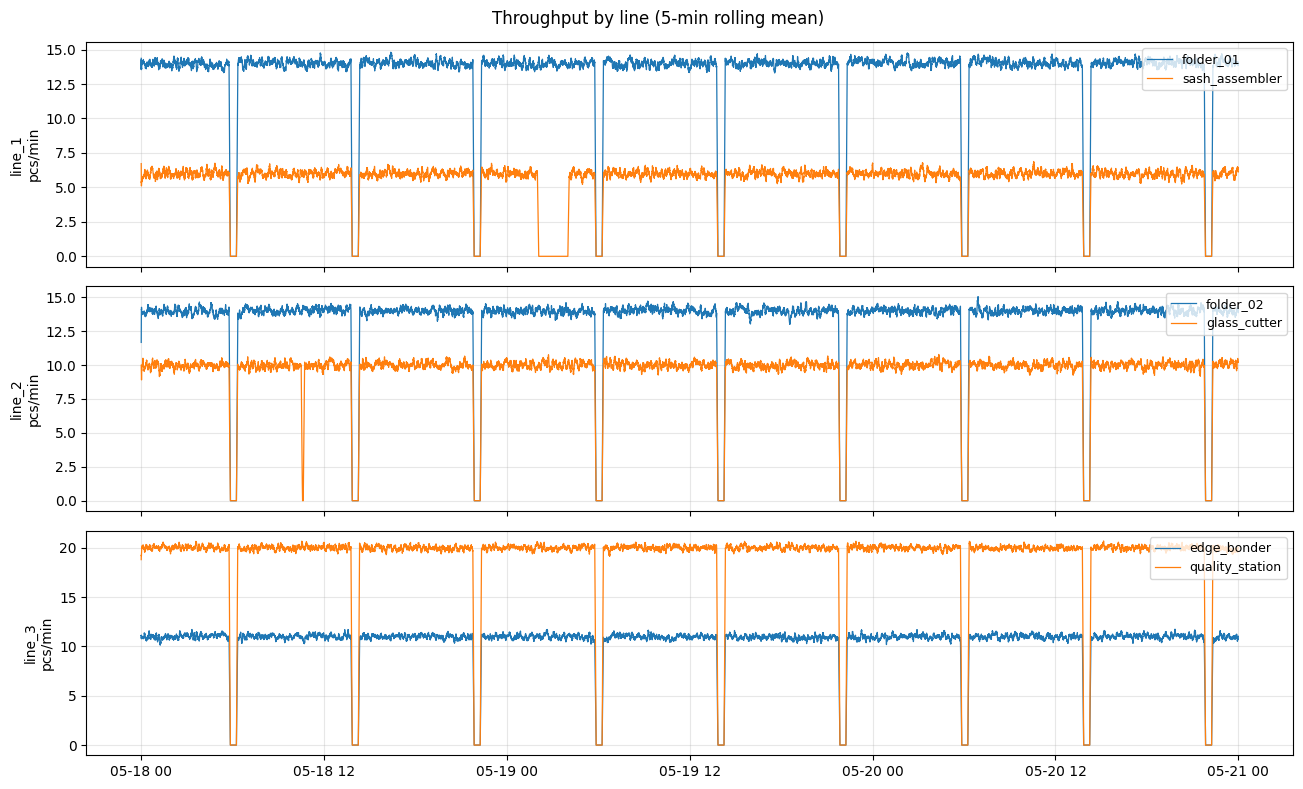

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, line in zip(axes, ['line_1', 'line_2', 'line_3']):
    sub = measurements[(measurements.line_id == line) &
                       (measurements.signal == 'throughput_pcs_per_min')]
    for mid, grp in sub.groupby('machine_id'):
        g = grp.set_index('timestamp').value.rolling('5min').mean()
        ax.plot(g.index, g.values, label=mid, linewidth=0.9)
    ax.set_ylabel(f'{line}\npcs/min')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('Throughput by line (5-min rolling mean)')
plt.tight_layout()
plt.show()

## Sanity check 2 — bearing wear on `line_2 / folder_02`

Baseline vibration around 2.5 mm/s when running. From 18:00 day 1 it ramps to a
peak around 2.2× baseline by day 2 morning, then holds. A spike at 09:30 day 2
represents the moment a real bearing might shed material.

Vertical lines show the alarms in the events log.

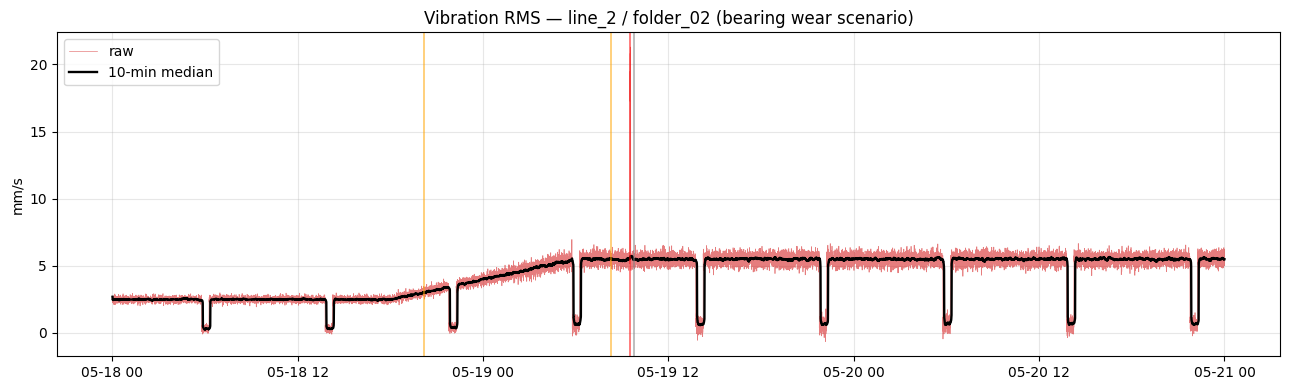

In [4]:
sub = measurements[(measurements.machine_id == 'folder_02') &
                   (measurements.signal == 'vibration_rms_mm_s')]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sub.timestamp, sub.value, linewidth=0.5, color='C3', alpha=0.6, label='raw')
rolling = sub.set_index('timestamp').value.rolling('10min').median()
ax.plot(rolling.index, rolling.values, linewidth=1.7, color='black', label='10-min median')
for _, ev in events[events.machine_id == 'folder_02'].iterrows():
    color = {'warning': 'orange', 'error': 'red', 'info': 'gray'}[ev.severity]
    ax.axvline(ev.timestamp, color=color, alpha=0.6, linewidth=1.2)
ax.set_title('Vibration RMS — line_2 / folder_02 (bearing wear scenario)')
ax.set_ylabel('mm/s')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sanity check 3 — stuck-at on `line_2 / glass_cutter`

Throughput collapses to zero at 10:30 day 1 for 8 minutes while motor current
stays at stall level (~5.5 A). This is the *correlation-break* anomaly: neither
current alone nor throughput alone looks anomalous, but the joint pattern is.

Classical single-signal thresholding misses this; isolation forest or a
multivariate model catches it. The LLM layer in `03_*` turns it into a
human-readable explanation.

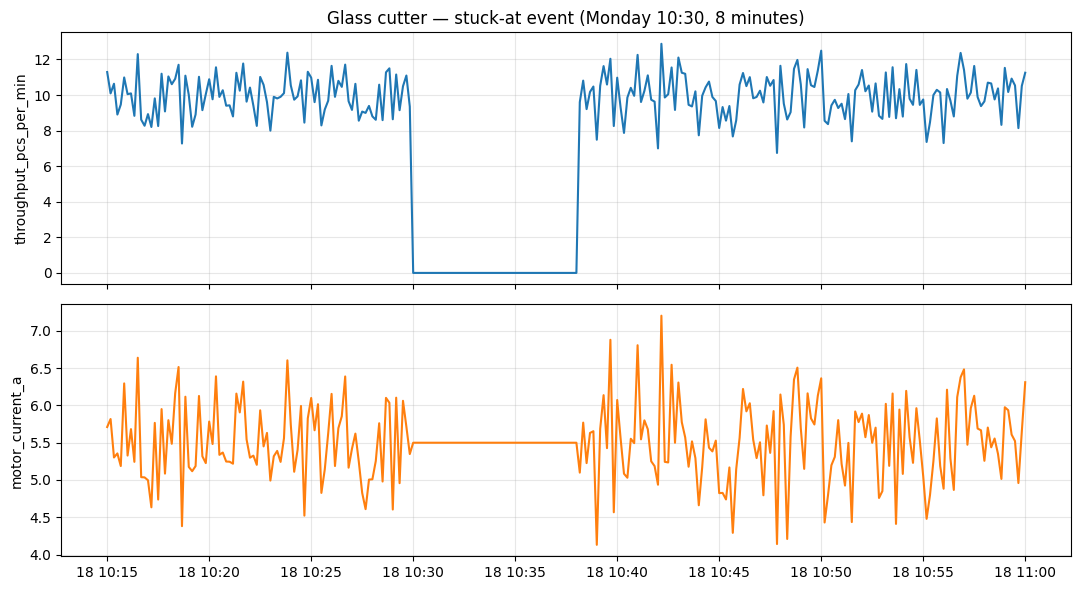

In [5]:
window = (pd.Timestamp('2026-05-18 10:15', tz='UTC'),
          pd.Timestamp('2026-05-18 11:00', tz='UTC'))
sub = measurements[(measurements.machine_id == 'glass_cutter') &
                   (measurements.timestamp.between(*window))]
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, sig, color in zip(axes,
                          ['throughput_pcs_per_min', 'motor_current_a'],
                          ['C0', 'C1']):
    s2 = sub[sub.signal == sig]
    ax.plot(s2.timestamp, s2.value, color=color)
    ax.set_ylabel(sig)
    ax.grid(True, alpha=0.3)
axes[0].set_title('Glass cutter — stuck-at event (Monday 10:30, 8 minutes)')
plt.tight_layout()
plt.show()

## Sanity check 4 — PackML state distribution and events

Most samples should be in `Execute`, with predictable amounts of `Idle` at
shift handovers. `sash_assembler` should have a chunk of `Stopped` (planned
maintenance) and `glass_cutter` should have some `Aborted` (the stuck-at).

In [6]:
state_counts = (
    measurements[measurements.signal == 'packml_state']
    .groupby(['machine_id', 'value_str'])
    .size()
    .unstack(fill_value=0)
)
print('PackML state samples per machine:')
print(state_counts.to_string())
print()
print('Events log:')
events[['timestamp', 'machine_id', 'event_type', 'severity', 'code', 'message']]

PackML state samples per machine:
value_str        Aborted  Execute  Idle  Stopped
machine_id                                      
edge_bonder            0    24354  1566        0
folder_01              0    24354  1566        0
folder_02              0    24354  1566        0
glass_cutter          49    24305  1566        0
quality_station        0    24354  1566        0
sash_assembler         0    23633  1566      721

Events log:


,timestamp,machine_id,event_type,severity,code,message
0,2026-05-18 10:30:00+00:00,glass_cutter,alarm,error,DRV_F042,Drive fault: motor over-current sustained. Che...
1,2026-05-18 10:32:00+00:00,glass_cutter,operator_note,info,OP_NOTE,Glas blev hængende på transportbåndet. Manuelt...
2,2026-05-18 10:38:00+00:00,glass_cutter,mes_message,info,RESUMED,Production resumed after manual intervention.
3,2026-05-18 20:10:00+00:00,folder_02,alarm,warning,VIB_W01,Vibration RMS rising above baseline (1.2x).
4,2026-05-19 02:00:00+00:00,sash_assembler,mes_message,info,PM_START,Planned maintenance window started. Estimated ...
5,2026-05-19 04:05:00+00:00,sash_assembler,mes_message,info,PM_END,Planned maintenance complete. Returning to pro...
6,2026-05-19 08:15:00+00:00,folder_02,alarm,warning,VIB_W02,Vibration RMS sustained above warning threshol...
7,2026-05-19 09:30:00+00:00,folder_02,alarm,error,VIB_E01,Vibration spike: 3.5x baseline. Inspect main b...
8,2026-05-19 09:45:00+00:00,folder_02,operator_note,info,OP_NOTE,Maskinen lyder anderledes. Vil have vedligehol...


## Sanity check 5 — correlations look like real motors

Motor current and throughput should be strongly correlated on a healthy line.
Anything much below 0.9 would be suspicious.

In [7]:
rows = []
for machine in measurements.machine_id.unique():
    wide = (measurements[(measurements.machine_id == machine) &
                         (measurements.signal.isin(['motor_current_a',
                                                    'throughput_pcs_per_min']))]
            .pivot_table(index='timestamp', columns='signal', values='value'))
    rows.append({'machine_id': machine,
                 'corr_current_throughput': wide.corr().iloc[0, 1].round(3)})
pd.DataFrame(rows)

,machine_id,corr_current_throughput
0,folder_01,0.985
1,sash_assembler,0.946
2,folder_02,0.985
3,glass_cutter,0.960
4,edge_bonder,0.977
5,quality_station,0.992


## Write to parquet

Two files: measurements (long format, mimics how a Kafka topic would look) and
events (alarms, MES messages, operator notes in Danish + English).

In [8]:
m_path, e_path = write_parquet(measurements, events, DATA_DIR)
print(f'measurements: {m_path}  ({m_path.stat().st_size / 1024:.0f} KB)')
print(f'events:       {e_path}  ({e_path.stat().st_size:,} B)')

measurements: ../data/synthetic_factory.parquet  (6665 KB)
events:       ../data/synthetic_events.parquet  (5,957 B)


## What's next

- `02_nl_query_demo.ipynb` — natural-language interface to this dataset (primary
  live demo for the talk).
- `03_hybrid_anomaly_demo.ipynb` — classical anomaly detection on the
  bearing-wear and stuck-at scenarios, plus a small LLM that turns the
  detected anomaly into a plain-language explanation with linked events.

Both notebooks load from `data/synthetic_factory.parquet` and
`data/synthetic_events.parquet`. They should not need to call `build_dataset`
directly.